## 월별 2023 데이터 합치고 성동구만 남기기

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 데이터 불러오기 
names = pd.read_csv("../Data/tpss_bcycl_od_statnhm_202312_merged.csv",encoding='utf-8',index_col=None)
names.head()



,기준_날짜,집계_기준,기준_시간,시작_대여소,시작_대여소명,종료_대여소,종료_대여소명,전체건수,전체_이용_분,전체_이용_거리
0,20231201,출발시간,0,ST-3249,이촌1동_006_1,ST-2184,이촌1동_045_1,1,1,0
1,20231201,출발시간,0,ST-595,면목5동_013_1,ST-2294,중화2동_038_1,1,7,1700
2,20231201,출발시간,0,ST-2577,방이1동_020_2,ST-1585,잠실3동_070_2,1,34,2277
3,20231201,출발시간,0,ST-1213,장위3동_011_1,ST-1106,번3동_003_1,1,2,264
4,20231201,출발시간,0,ST-1392,삼양동_032_1,ST-948,미아동_010_4,1,8,1100


In [3]:
# 대여소 아이디 받아오기 
id= pd.read_csv("../Data/따릉이_성동구_대여소.csv",encoding='utf8')
id=id['대여소_ID']


In [4]:
#id가 포함된 내용만 Ture 표시 
names['대여소_포함'] = names['시작_대여소'].isin(id) | names['종료_대여소'].isin(id)

In [5]:
names[names['대여소_포함']==True]

,기준_날짜,집계_기준,기준_시간,시작_대여소,시작_대여소명,종료_대여소,종료_대여소명,전체건수,전체_이용_분,전체_이용_거리,대여소_포함
8,20231201,출발시간,0,ST-361,송정동_002_1,ST-112,성수2가3동_016_1,1,5,1171,True
74,20231201,출발시간,0,ST-243,용답동_003_1,ST-1447,전농2동_037_1,1,15,2189,True
98,20231201,출발시간,0,ST-506,성수2가3동_021_2,ST-446,성수2가1동_020_1,1,6,880,True
225,20231201,출발시간,5,ST-111,성수1가2동_030_1,ST-446,성수2가1동_020_1,1,9,1295,True
279,20231201,도착시간,5,ST-361,송정동_002_1,ST-112,성수2가3동_016_1,1,5,1171,True
...,...,...,...,...,...,...,...,...,...,...,...
4167188,20231231,도착시간,2355,ST-2420,사근동_007_2,ST-145,종로1·2·3·4가동_014_1,1,30,6170,True
4167190,20231231,도착시간,2355,ST-249,사근동_017_1,ST-274,용신동_028_1,1,20,2780,True
4167194,20231231,도착시간,2355,ST-368,성수2가3동_002_3,ST-103,송정동_023_1,1,4,520,True
4167217,20231231,도착시간,2355,ST-237,행당1동_009_1,ST-176,숭인2동_014_1,1,15,1848,True


In [6]:
names = names[names['대여소_포함']]


In [7]:
names.columns

Index(['기준_날짜', '집계_기준', '기준_시간', '시작_대여소', '시작_대여소명', '종료_대여소', '종료_대여소명',
       '전체건수', '전체_이용_분', '전체_이용_거리', '대여소_포함'],
      dtype='object')

In [8]:
# 컬럼 사이 공백 지우기 
names.columns = names.columns.str.strip()

In [9]:
filtered = names[
    (names['전체건수'] >= 2) &
    (names['집계_기준'] == '도착시간')
]

filtered.head()

,기준_날짜,집계_기준,기준_시간,시작_대여소,시작_대여소명,종료_대여소,종료_대여소명,전체건수,전체_이용_분,전체_이용_거리,대여소_포함
6248,20231201,도착시간,225,ST-1440,황학동_011_1,ST-1198,왕십리도선동_028_2,2,17,2032,True
12117,20231201,도착시간,615,ST-178,창신3동_003_1,ST-1198,왕십리도선동_028_2,2,20,3520,True
14825,20231201,도착시간,650,ST-243,용답동_003_1,ST-2333,용답동_002_1,2,34,1911,True
15018,20231201,도착시간,650,ST-482,성수2가3동_021_1,ST-108,성수1가1동_014_2,2,16,2083,True
16569,20231201,도착시간,710,ST-446,성수2가1동_020_1,ST-506,성수2가3동_021_2,3,14,2484,True


In [172]:
names = names[['기준_날짜', '기준_시간', '시작_대여소', '종료_대여소', '전체_이용_분', '전체_이용_거리']]



In [173]:
names['대여'] = names['시작_대여소'].isin(id)
names['반납'] = names['종료_대여소'].isin(id)

In [174]:
names

,기준_날짜,기준_시간,시작_대여소,종료_대여소,전체_이용_분,전체_이용_거리,대여,반납
8,20231201,0,ST-361,ST-112,5,1171,True,True
74,20231201,0,ST-243,ST-1447,15,2189,True,False
98,20231201,0,ST-506,ST-446,6,880,True,True
225,20231201,5,ST-111,ST-446,9,1295,True,True
279,20231201,5,ST-361,ST-112,5,1171,True,True
...,...,...,...,...,...,...,...,...
4167188,20231231,2355,ST-2420,ST-145,30,6170,True,False
4167190,20231231,2355,ST-249,ST-274,20,2780,True,False
4167194,20231231,2355,ST-368,ST-103,4,520,True,True
4167217,20231231,2355,ST-237,ST-176,15,1848,True,False


In [175]:
names.to_csv("../Data/tpss_filtered_202312.csv", index=False, encoding='utf-8-sig')

In [176]:
import pandas as pd

# 삭제 대상 대여소 ID
remove_ids = ['ST-1738', 'ST-1737']

# 대상 파일들 (원하는 연도 변경 가능)
csv_files = [f'../Data/tpss_filtered_2023{i:02d}.csv' for i in range(1, 13)]

# 파일 반복 처리
for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='cp949')
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(file, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(file, encoding='utf-8-sig')

    # 삭제 조건 적용
    df = df[~(
        df['시작_대여소ID'].isin(remove_ids) |
        df['종료_대여소ID'].isin(remove_ids)
    )]

    # 덮어쓰기 저장
    df.to_csv(file, index=False, encoding='cp949')

print("모든 파일에서 ST-1738 및 ST-1737 관련 데이터가 제거되었습니다.")

모든 파일에서 ST-1738 및 ST-1737 관련 데이터가 제거되었습니다.


In [177]:
import pandas as pd

# 대상 CSV 파일 목록
csv_files = [
    '../Data/tpss_filtered_202301.csv', '../Data/tpss_filtered_202302.csv', '../Data/tpss_filtered_202303.csv', '../Data/tpss_filtered_202304.csv',
    '../Data/tpss_filtered_202305.csv', '../Data/tpss_filtered_202306.csv', '../Data/tpss_filtered_202307.csv', '../Data/tpss_filtered_202308.csv',
    '../Data/tpss_filtered_202309.csv', '../Data/tpss_filtered_202310.csv', '../Data/tpss_filtered_202311.csv', '../Data/tpss_filtered_202312.csv'
]

# 각 파일에 대해 처리 및 덮어쓰기
for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='cp949')
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(file, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(file, encoding='utf-8-sig')
    
    df_cleaned = df[
        (df['전체이용시간(분)'] != 0) &
        (df['시작_대여소ID'] != df['종료_대여소ID']) &
        (df['전체이용거리(m)'] != 0.0)
    ]
    df_cleaned.to_csv(file, index=False, encoding='cp949')

print("모든 파일이 정상적으로 필터링 및 저장되었습니다.")

모든 파일이 정상적으로 필터링 및 저장되었습니다.


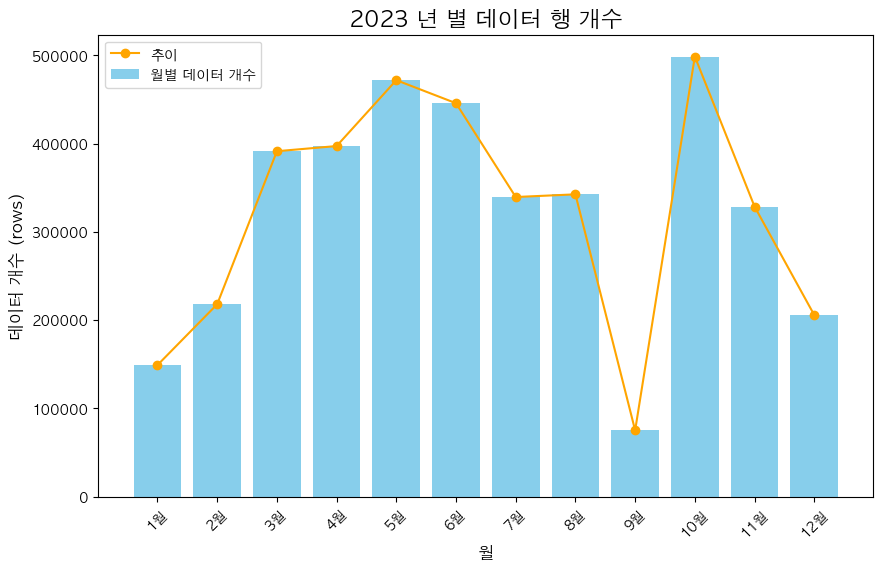

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Mac)
matplotlib.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

# 파일 리스트 (1월~12월 CSV 경로 직접 넣기)
csv_files = [
    '../Data/tpss_filtered_202301.csv', '../Data/tpss_filtered_202302.csv', '../Data/tpss_filtered_202303.csv', '../Data/tpss_filtered_202304.csv',
    '../Data/tpss_filtered_202305.csv', '../Data/tpss_filtered_202306.csv', '../Data/tpss_filtered_202307.csv', '../Data/tpss_filtered_202308.csv',
    '../Data/tpss_filtered_202309.csv', '../Data/tpss_filtered_202310.csv', '../Data/tpss_filtered_202311.csv', '../Data/tpss_filtered_202312.csv'
]

# 월별 데이터 개수 저장할 리스트
month_counts = []

# 각 파일에서 데이터 개수 세기
for file in csv_files:
    df = pd.read_csv(file, encoding='cp949')  # 인코딩 필요시 cp949로 변경
    count = len(df)
    month_counts.append(count)

# 월 레이블
months = [f"{i}월" for i in range(1, 13)]

# 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(months, month_counts, color='skyblue', label='월별 데이터 개수')
plt.plot(months, month_counts, color='orange', marker='o', linestyle='-', label='추이')

# 꾸미기
plt.title('2023 년 별 데이터 행 개수', fontsize=16)
plt.xlabel('월', fontsize=12)
plt.ylabel('데이터 개수 (rows)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

plt.show()

